# Exploracio EDA - Fractionation Dataset

Analisi exploratoria del dataset de fraccionament de plasma.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Carrega de dades

In [2]:
df = pd.read_csv('../../../data/fractionation_data.csv')
print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Shape: (4616, 151)
Rows: 4616, Columns: 151


/var/folders/jr/swhc70v52yqbt5xhyvfcyzn40000gp/T/ipykernel_6946/2294127029.py:1: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../../data/fractionation_data.csv')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4616 entries, 0 to 4615
Columns: 151 entries, A1 to CRATES_STAGING
dtypes: float64(118), int64(9), object(24)
memory usage: 5.3+ MB


In [4]:
df.describe()

,B3,B4,B7,B8,B10,B11,B12,B13,B14,B15,...,D55,D56,D57,D58,D59,D60,D61,D62,D63,CRATES_STAGING
count,4120.000000,2298.000000,2547.000000,4616.000000,3163.000000,3163.000000,3163.000000,3163.000000,4616.000000,4616.000000,...,4611.000000,4607.000000,4607.000000,4607.000000,4607.000000,4613.000000,4597.000000,2264.000000,97.000000,4616.000000
mean,16.915983,1.971473,103.755006,7.996425,1.558963,1.441985,1.553272,1.443566,22.592873,22.496685,...,31.159618,4.647562,16.767243,33.528715,45.245149,65.953296,29.832105,15.458024,92.618557,0.050260
std,3.612866,0.433800,54.294523,1.612987,0.496590,0.496701,0.497233,0.496884,4.147388,4.139694,...,1.814770,1.446996,1.666986,2.311086,1.834579,4.950566,2.394701,35.244656,7.238717,0.218505
min,9.750000,0.000000,64.000000,-62.916667,1.000000,1.000000,1.000000,1.000000,10.000000,10.000000,...,27.000000,1.100000,11.500000,13.600000,40.600000,0.000000,0.000000,0.000000,74.500000,0.000000
25%,14.500000,1.705556,74.000000,7.300000,1.000000,1.000000,1.000000,1.000000,20.000000,20.000000,...,30.000000,3.600000,15.600000,32.600000,44.000000,62.790000,28.240000,0.963344,88.500000,0.000000
50%,16.300000,1.840741,88.000000,7.800000,2.000000,1.000000,2.000000,1.000000,25.000000,25.000000,...,31.000000,4.700000,16.600000,33.900000,45.100000,65.730000,29.670000,1.034445,91.700000,0.000000
75%,18.500000,2.107407,111.500000,8.416667,2.000000,2.000000,2.000000,2.000000,25.000000,25.000000,...,32.000000,5.700000,17.800000,34.900000,46.400000,68.882000,31.240000,1.135403,95.300000,0.000000
max,46.200000,4.790000,735.000000,32.900000,2.000000,2.000000,2.000000,2.000000,35.000000,37.000000,...,42.000000,34.900000,34.400000,42.800000,55.900000,88.158000,43.154432,127.161533,115.000000,1.000000


## 2. Valors perduts (Missing Values)

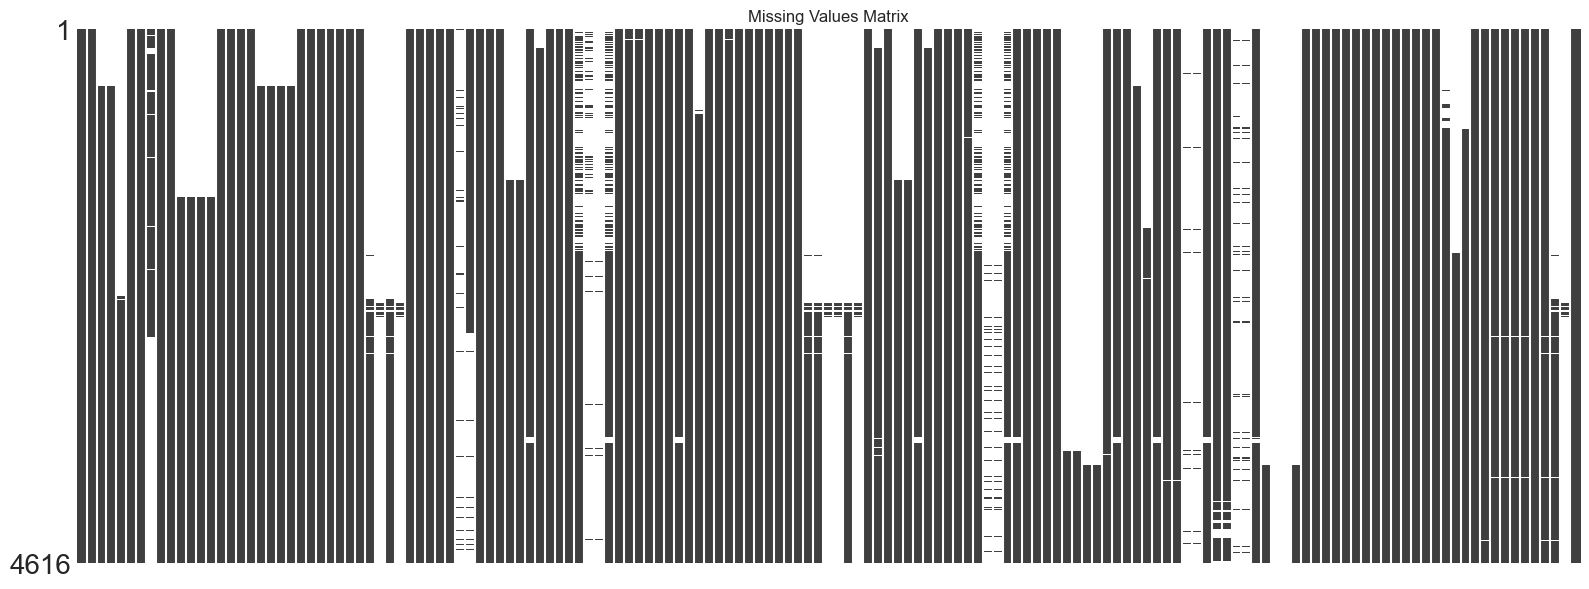

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))
msno.matrix(df, ax=ax, sparkline=False)
plt.title('Missing Values Matrix')
plt.tight_layout()
plt.show()

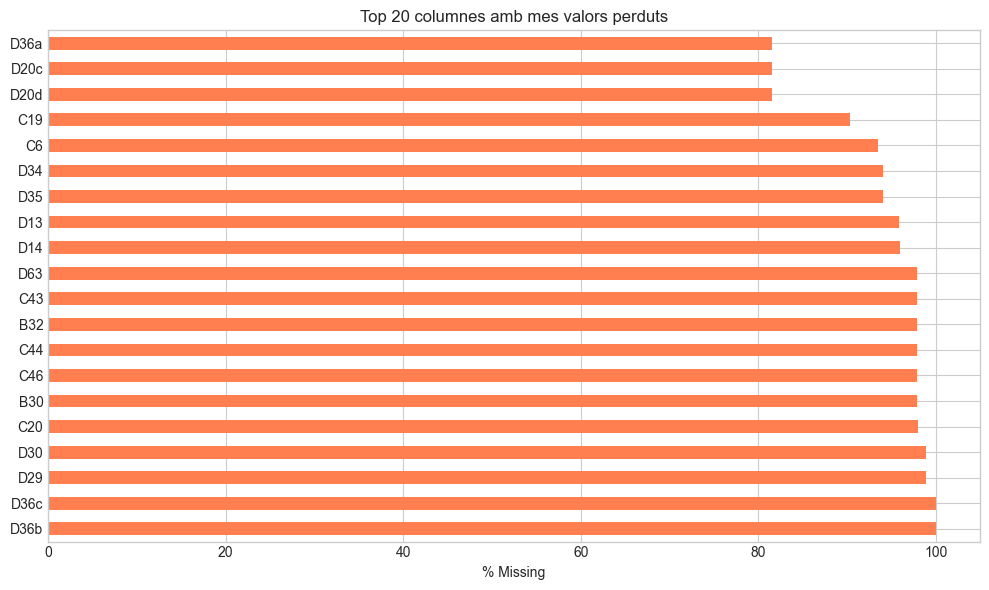

In [6]:
# Percentatge de missings per columna (top 20)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
top_missing = missing_pct[missing_pct > 0].head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_missing.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('% Missing')
ax.set_title('Top 20 columnes amb mes valors perduts')
plt.tight_layout()
plt.show()

## 3. Distribucio de la variable objectiu D49

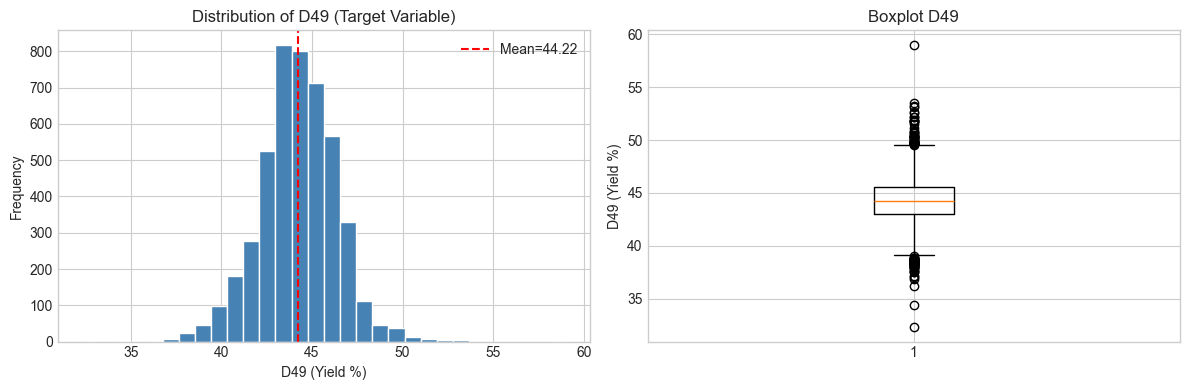

D49 stats:
count    4616.000000
mean       44.220915
std         2.121902
min        32.300000
25%        42.977907
50%        44.217538
75%        45.600000
max        59.013370
Name: D49, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['D49'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('D49 (Yield %)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of D49 (Target Variable)')
axes[0].axvline(df['D49'].mean(), color='red', linestyle='--', label=f'Mean={df["D49"].mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['D49'].dropna(), vert=True)
axes[1].set_ylabel('D49 (Yield %)')
axes[1].set_title('Boxplot D49')

plt.tight_layout()
plt.show()

print(f'D49 stats:')
print(df['D49'].describe())

## 4. Correlacio entre variables numeriques (Top 20)

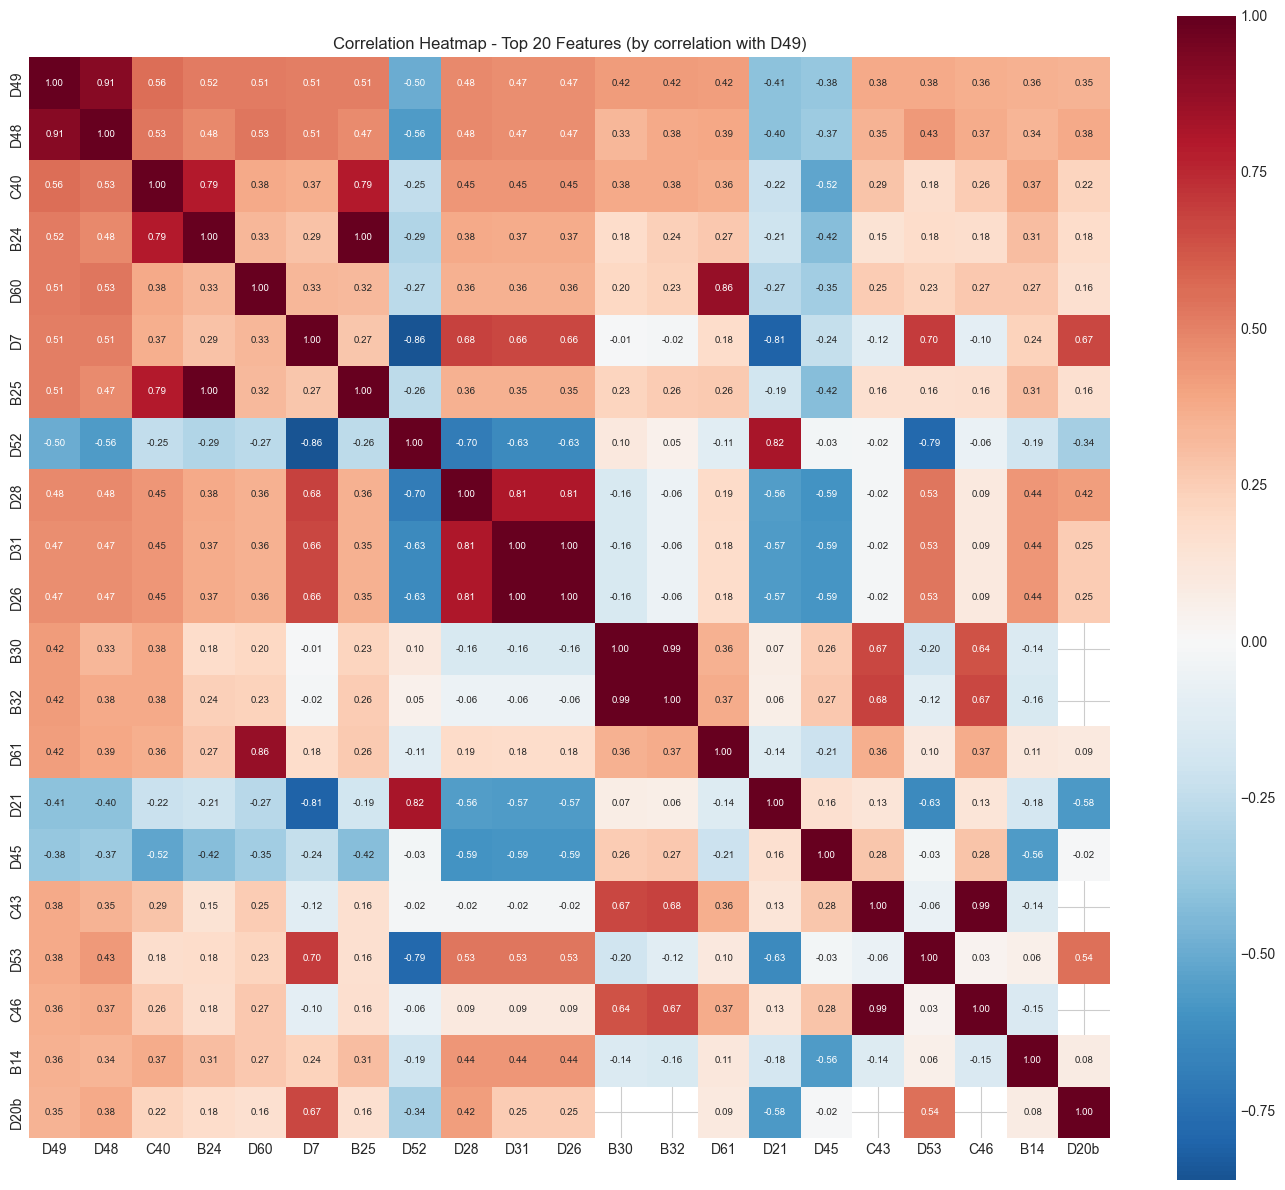

In [8]:
# Select numeric columns and compute correlation with D49
numeric_df = df.select_dtypes(include=[np.number])

# Get top 20 features most correlated with D49
if 'D49' in numeric_df.columns:
    corr_with_target = numeric_df.corr()['D49'].abs().sort_values(ascending=False)
    top_20_cols = corr_with_target.head(21).index.tolist()  # 21 because includes D49 itself
else:
    top_20_cols = numeric_df.columns[:20].tolist()

corr_matrix = numeric_df[top_20_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap - Top 20 Features (by correlation with D49)')
plt.tight_layout()
plt.show()